# Importing Libraries & Loading Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

pd.set_option('display.max_columns', None)

In [2]:
AEP = pd.read_csv('./Dataset/AEP_hourly.csv')
COMED = pd.read_csv('./Dataset/COMED_hourly.csv')
DAYTON = pd.read_csv('./Dataset/DAYTON_hourly.csv')
DEOK = pd.read_csv('./Dataset/DEOK_hourly.csv')
DOM = pd.read_csv('./Dataset/DOM_hourly.csv')
DUQ = pd.read_csv('./Dataset/DUQ_hourly.csv')
EKPC = pd.read_csv('./Dataset/EKPC_hourly.csv')
FE = pd.read_csv('./Dataset/FE_hourly.csv')
NI = pd.read_csv('./Dataset/NI_hourly.csv')

PJM = pd.read_csv('./Dataset/PJM_Load_hourly.csv')
PJME = pd.read_csv('./Dataset/PJME_hourly.csv')
PJMW = pd.read_csv('./Dataset/PJMW_hourly.csv')

# Data Understanding

In [3]:
dfs = [AEP, COMED, DAYTON, DEOK, DOM, DUQ, EKPC, FE, NI]
total_sum = 0
for i in range(len(dfs)):
    print(f"Dataset {i+1} shape: {dfs[i].shape}")
    total_sum += dfs[i].shape[0]
    
print(f"\n\nPJM dataset shape: {PJM.shape}")
print(f"PJME dataset shape: {PJME.shape}")
print(f"PJMW dataset shape: {PJMW.shape}")
print(f"\n\nTotal number of rows across all base datasets: {total_sum}")

Dataset 1 shape: (121273, 2)
Dataset 2 shape: (66497, 2)
Dataset 3 shape: (121275, 2)
Dataset 4 shape: (57739, 2)
Dataset 5 shape: (116189, 2)
Dataset 6 shape: (119068, 2)
Dataset 7 shape: (45334, 2)
Dataset 8 shape: (62874, 2)
Dataset 9 shape: (58450, 2)


PJM dataset shape: (32896, 2)
PJME dataset shape: (145366, 2)
PJMW dataset shape: (143206, 2)


Total number of rows across all base datasets: 768699


In [4]:
PJM.head()

,Datetime,PJM_Load_MW
0,1998-12-31 01:00:00,29309.0
1,1998-12-31 02:00:00,28236.0
2,1998-12-31 03:00:00,27692.0
3,1998-12-31 04:00:00,27596.0
4,1998-12-31 05:00:00,27888.0


In [5]:
PJME.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [6]:
PJMW.head()

,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077.0
1,2002-12-31 02:00:00,4939.0
2,2002-12-31 03:00:00,4885.0
3,2002-12-31 04:00:00,4857.0
4,2002-12-31 05:00:00,4930.0


In [7]:
PJM['Datetime'].min(), PJM['Datetime'].max()

('1998-04-01 01:00:00', '2002-01-01 00:00:00')

In [8]:
PJME['Datetime'].min(), PJME['Datetime'].max()

('2002-01-01 01:00:00', '2018-08-03 00:00:00')

In [9]:
PJMW['Datetime'].min(), PJMW['Datetime'].max()

('2002-04-01 01:00:00', '2018-08-03 00:00:00')

In [10]:
for i in range(len(dfs)):
    print(f"Dataset {i+1} min/max dates:")
    print(dfs[i]['Datetime'].min())
    print(dfs[i]['Datetime'].max())
    print("\n\n")

Dataset 1 min/max dates:
2004-10-01 01:00:00
2018-08-03 00:00:00



Dataset 2 min/max dates:
2011-01-01 01:00:00
2018-08-03 00:00:00



Dataset 3 min/max dates:
2004-10-01 01:00:00
2018-08-03 00:00:00



Dataset 4 min/max dates:
2012-01-01 01:00:00
2018-08-03 00:00:00



Dataset 5 min/max dates:
2005-05-01 01:00:00
2018-08-03 00:00:00



Dataset 6 min/max dates:
2005-01-01 01:00:00
2018-08-03 00:00:00



Dataset 7 min/max dates:
2013-06-01 01:00:00
2018-08-03 00:00:00



Dataset 8 min/max dates:
2011-06-01 01:00:00
2018-08-03 00:00:00



Dataset 9 min/max dates:
2004-05-01 01:00:00
2011-01-01 00:00:00





# Merging DataFrames

In [11]:
labels = ["Amercian Electric Power", "Comed", "Dayton Power & Light", "Duke Energy Ohio", "Dominion Energy", "Duquesne Light Company", 
          "East Kentucky Power Cooperative", "FirstEnergy", "Comed"] #NOTE: Northern Illinois dataset is also from COMED, so we will merge them together

for i in range(len(dfs)):
    dfs[i]["Company"] = labels[i]

AEP.head()

,Datetime,AEP_MW,Company
0,2004-12-31 01:00:00,13478.0,Amercian Electric Power
1,2004-12-31 02:00:00,12865.0,Amercian Electric Power
2,2004-12-31 03:00:00,12577.0,Amercian Electric Power
3,2004-12-31 04:00:00,12517.0,Amercian Electric Power
4,2004-12-31 05:00:00,12670.0,Amercian Electric Power


In [12]:
for i in range(len(dfs)):
    dfs[i].columns = ['Datetime', 'Energy_Consumption', 'Company']

AEP.head()

,Datetime,Energy_Consumption,Company
0,2004-12-31 01:00:00,13478.0,Amercian Electric Power
1,2004-12-31 02:00:00,12865.0,Amercian Electric Power
2,2004-12-31 03:00:00,12577.0,Amercian Electric Power
3,2004-12-31 04:00:00,12517.0,Amercian Electric Power
4,2004-12-31 05:00:00,12670.0,Amercian Electric Power


In [13]:
df = pd.concat(dfs, ignore_index=True)
df.head()

,Datetime,Energy_Consumption,Company
0,2004-12-31 01:00:00,13478.0,Amercian Electric Power
1,2004-12-31 02:00:00,12865.0,Amercian Electric Power
2,2004-12-31 03:00:00,12577.0,Amercian Electric Power
3,2004-12-31 04:00:00,12517.0,Amercian Electric Power
4,2004-12-31 05:00:00,12670.0,Amercian Electric Power


In [14]:
len(df)

768699

In [15]:
df["Company"].value_counts()

Company
Comed                              124947
Dayton Power & Light               121275
Amercian Electric Power            121273
Duquesne Light Company             119068
Dominion Energy                    116189
FirstEnergy                         62874
Duke Energy Ohio                    57739
East Kentucky Power Cooperative     45334
Name: count, dtype: int64

In [16]:
PJM.columns = ['Datetime', 'PJME_MW']
PJME_New = pd.concat([PJM, PJME])
PJME_New.head()

,Datetime,PJME_MW
0,1998-12-31 01:00:00,29309.0
1,1998-12-31 02:00:00,28236.0
2,1998-12-31 03:00:00,27692.0
3,1998-12-31 04:00:00,27596.0
4,1998-12-31 05:00:00,27888.0


In [17]:
PJM.columns = ['Datetime', 'PJMW_MW']
PJMW_New = pd.concat([PJM, PJMW])
PJMW_New.head()

,Datetime,PJMW_MW
0,1998-12-31 01:00:00,29309.0
1,1998-12-31 02:00:00,28236.0
2,1998-12-31 03:00:00,27692.0
3,1998-12-31 04:00:00,27596.0
4,1998-12-31 05:00:00,27888.0


In [18]:
PJM_Regions = pd.merge(PJME_New, PJMW_New, on='Datetime', how='inner')
PJM_Regions.columns = ['Datetime', 'PJM_East', 'PJM_West']
PJM_Regions.head()

,Datetime,PJM_East,PJM_West
0,1998-12-31 01:00:00,29309.0,29309.0
1,1998-12-31 02:00:00,28236.0,28236.0
2,1998-12-31 03:00:00,27692.0,27692.0
3,1998-12-31 04:00:00,27596.0,27596.0
4,1998-12-31 05:00:00,27888.0,27888.0


# Data Cleaning & Preprocessing

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768699 entries, 0 to 768698
Data columns (total 3 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Datetime            768699 non-null  object 
 1   Energy_Consumption  768699 non-null  float64
 2   Company             768699 non-null  object 
dtypes: float64(1), object(2)
memory usage: 17.6+ MB


In [20]:
df.describe()

,Energy_Consumption
count,768699.000000
mean,7513.291724
std,5586.572163
min,0.000000
25%,1939.000000
50%,7724.000000
75%,11954.000000
max,25695.000000


In [21]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
PJM_Regions["Datetime"] = pd.to_datetime(PJM_Regions["Datetime"])

In [22]:
PJM_Regions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176110 entries, 0 to 176109
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  176110 non-null  datetime64[ns]
 1   PJM_East  176110 non-null  float64       
 2   PJM_West  176110 non-null  float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 4.0 MB


In [23]:
PJM_Regions.describe()

,Datetime,PJM_East,PJM_West
count,176110,176110.000000,176110.000000
mean,2008-06-29 23:33:57.696894208,31672.408938,10115.968968
min,1998-04-01 01:00:00,14544.000000,487.000000
25%,2003-07-08 23:15:00,27179.000000,5073.000000
50%,2008-07-16 20:30:00,31062.000000,5823.000000
75%,2013-07-25 18:45:00,35231.000000,7088.000000
max,2018-08-03 00:00:00,62009.000000,54030.000000
std,NaN,6439.131865,9791.211624


In [24]:
df.sort_values(by='Datetime', inplace=True)
PJM_Regions.sort_values(by='Datetime', inplace=True)

In [25]:
df.drop_duplicates(inplace=True)
PJM_Regions.drop_duplicates(inplace=True)

len(df)

768699

In [26]:
PJM_Regions = PJM_Regions.melt(
    id_vars=['Datetime'], 
    value_vars=['PJM_East', 'PJM_West'], 
    var_name='PJM', 
    value_name='Energy_Consumption'
)
PJM_Regions.head()

,Datetime,PJM,Energy_Consumption
0,1998-04-01 01:00:00,PJM_East,22259.0
1,1998-04-01 02:00:00,PJM_East,21244.0
2,1998-04-01 03:00:00,PJM_East,20651.0
3,1998-04-01 04:00:00,PJM_East,20421.0
4,1998-04-01 05:00:00,PJM_East,20713.0


In [27]:
len(PJM_Regions)

352220

# Exploratory Data Analysis

C:\Users\Mohamed\AppData\Local\Temp\ipykernel_12384\675318547.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


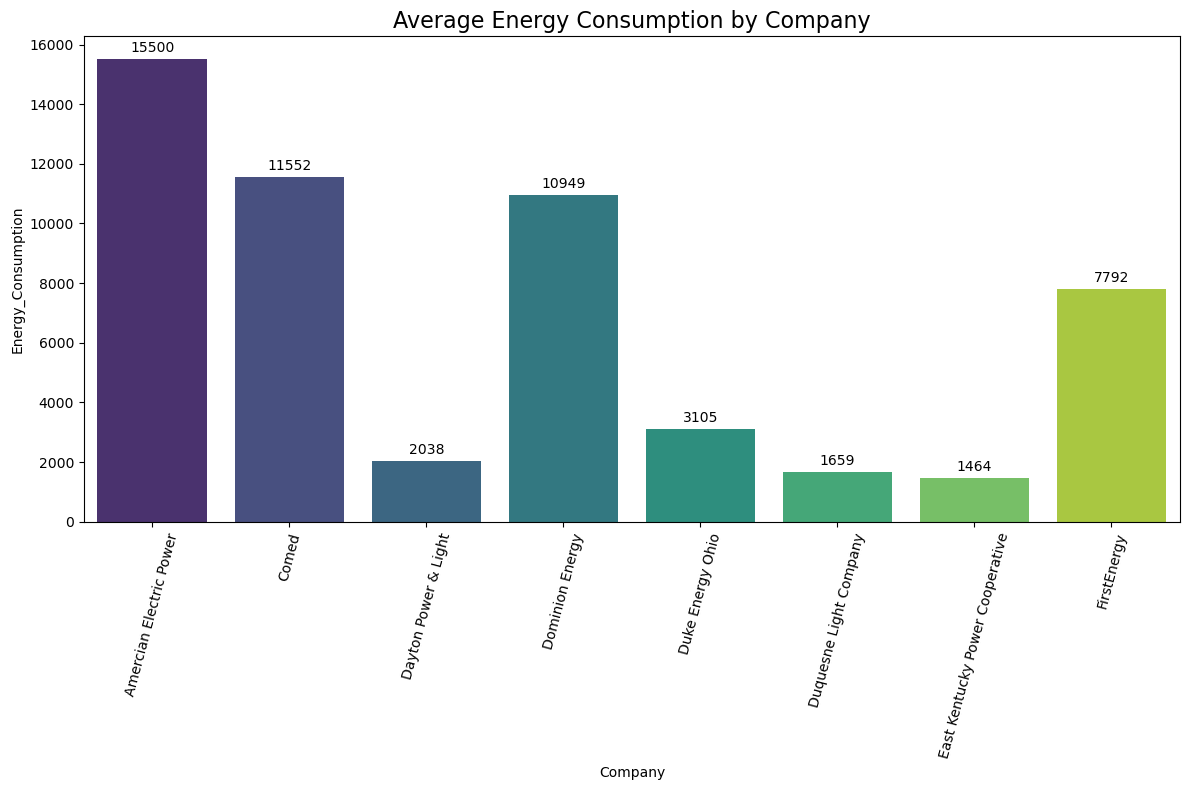

In [28]:
groups = df.groupby('Company')["Energy_Consumption"].mean().reset_index()
fig, ax = plt.subplots(figsize=(12, 8))

bars = sns.barplot(
    data=groups, 
    x='Company', 
    y='Energy_Consumption', 
    palette='viridis', 
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=10, padding=3)

ax.set_title('Average Energy Consumption by Company', fontsize=16)
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

C:\Users\Mohamed\AppData\Local\Temp\ipykernel_12384\1835554822.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


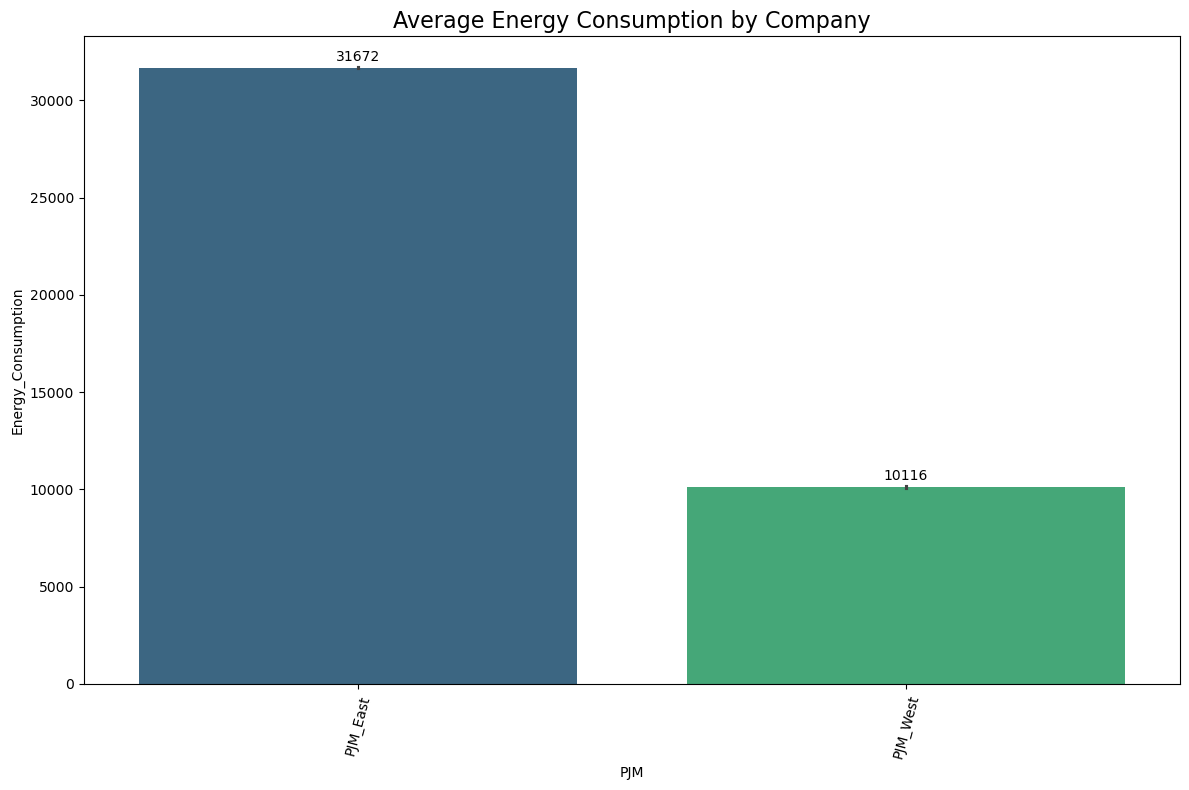

In [29]:
fig, ax = plt.subplots(figsize=(12, 8))
bars = sns.barplot(
    data=PJM_Regions, 
    x='PJM', 
    y='Energy_Consumption', 
    palette='viridis',
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=10, padding=3)

ax.set_title('Average Energy Consumption by Company', fontsize=16)
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

C:\Users\Mohamed\AppData\Local\Temp\ipykernel_12384\1682760952.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


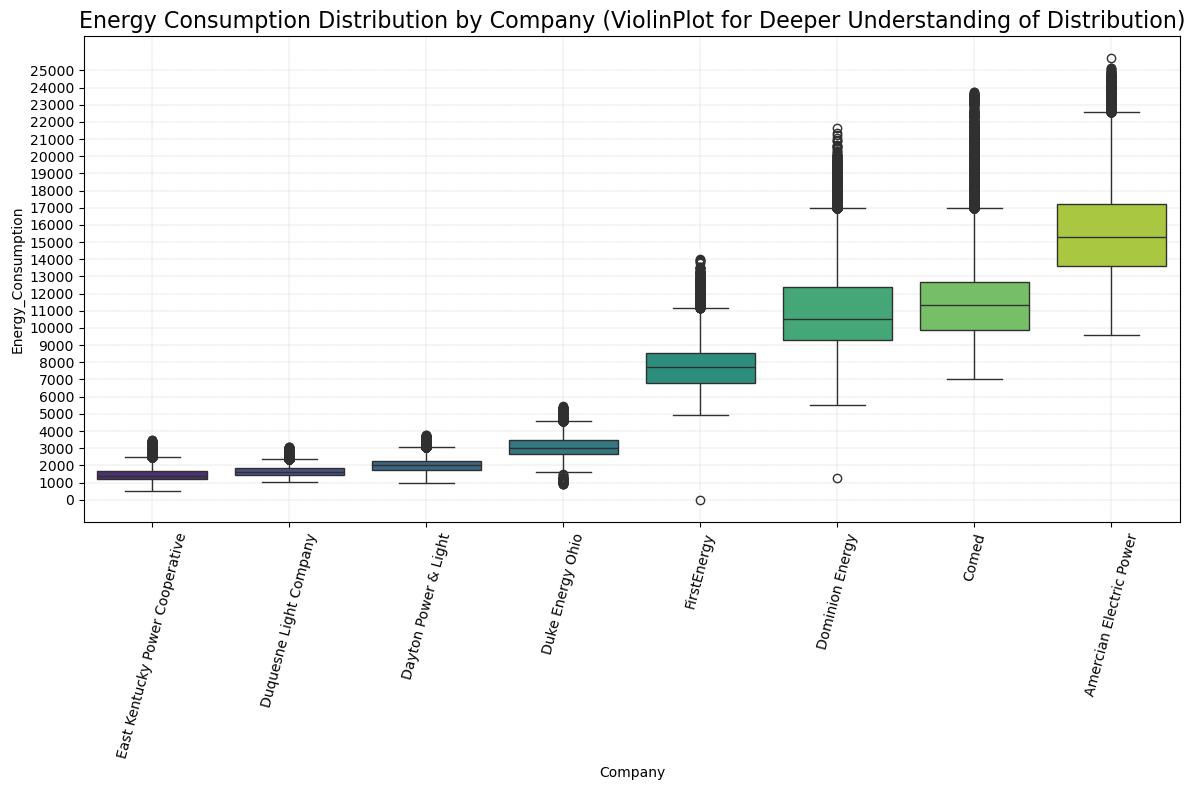

In [30]:
company_means = df.groupby('Company')['Energy_Consumption'].mean().sort_values()
ordered_companies = company_means.index.tolist()

ranges = np.arange(0, 26000, 1000)
fig, ax = plt.subplots(figsize=(12, 8))

sns.boxplot(
    data=df, 
    x='Company', 
    y='Energy_Consumption', 
    palette='viridis',
    order=ordered_companies,
    ax=ax
)

ax.set_title('Energy Consumption Distribution by Company (ViolinPlot for Deeper Understanding of Distribution)', fontsize=16)
plt.xticks(rotation=75)
plt.yticks(ranges)
plt.grid(True, which='both', linestyle='--', linewidth=0.25)
plt.tight_layout()
plt.show()

C:\Users\Mohamed\AppData\Local\Temp\ipykernel_12384\3370772341.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


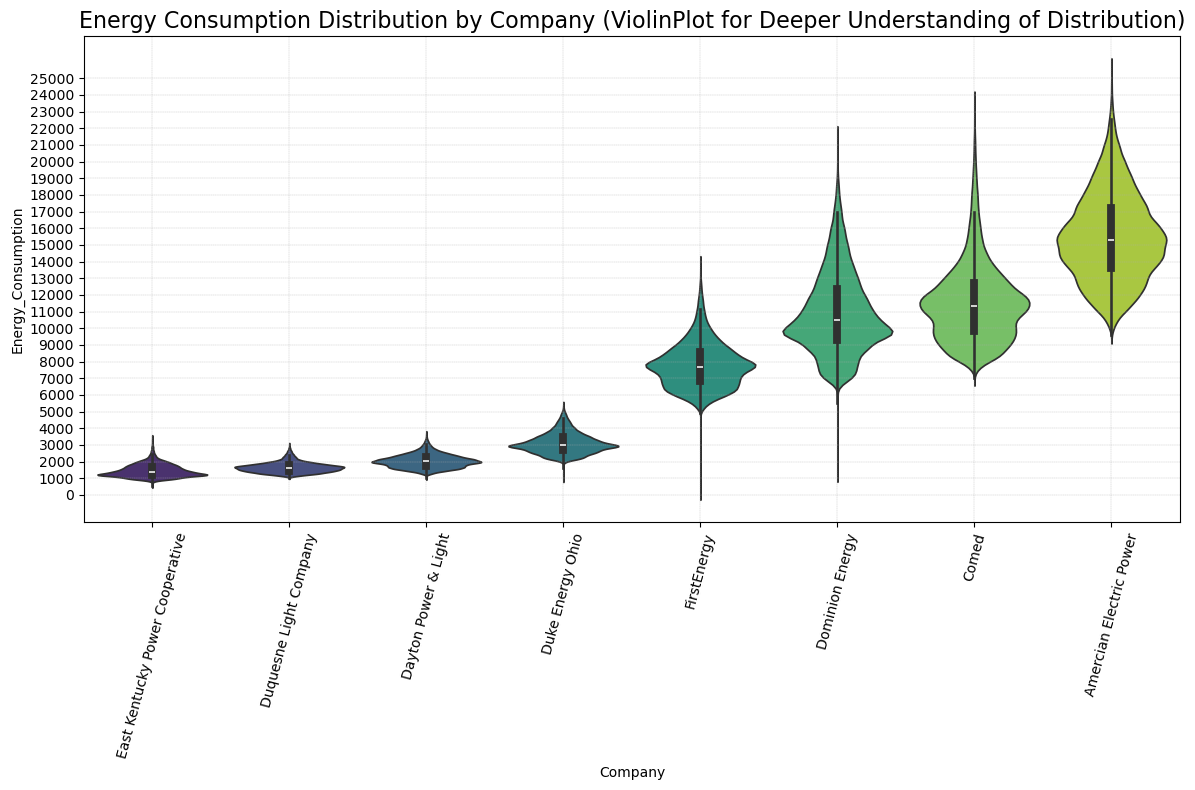

In [31]:
fig, ax = plt.subplots(figsize=(12, 8))

sns.violinplot(
    data=df, 
    x='Company', 
    y='Energy_Consumption', 
    palette='viridis',
    order=ordered_companies,
    ax=ax
)

ax.set_title('Energy Consumption Distribution by Company (ViolinPlot for Deeper Understanding of Distribution)', fontsize=16)
plt.xticks(rotation=75)
plt.yticks(ranges)
plt.grid(True, which='both', linestyle='--', linewidth=0.25)
plt.tight_layout()
plt.show()

C:\Users\Mohamed\AppData\Local\Temp\ipykernel_12384\2277513727.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


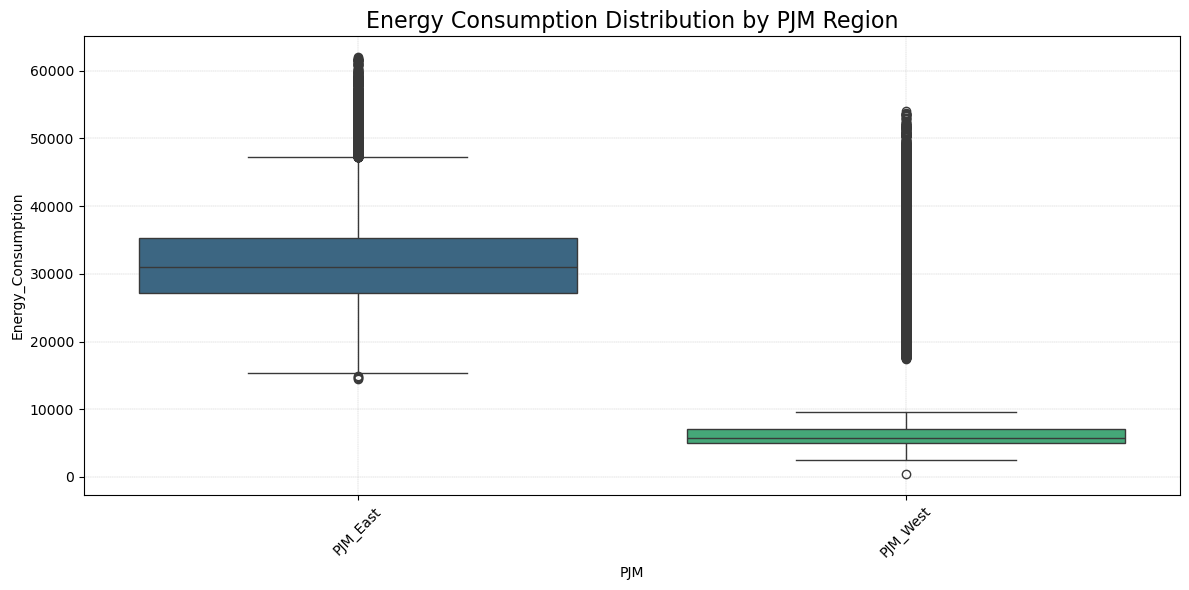

In [32]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=PJM_Regions,
    x='PJM',
    y='Energy_Consumption',
    palette='viridis'
)
plt.xticks(rotation=45)
plt.title('Energy Consumption Distribution by PJM Region', fontsize=16)
plt.grid(True, which='both', linestyle='--', linewidth=0.25)
plt.tight_layout()
plt.show()

C:\Users\Mohamed\AppData\Local\Temp\ipykernel_12384\3603296278.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


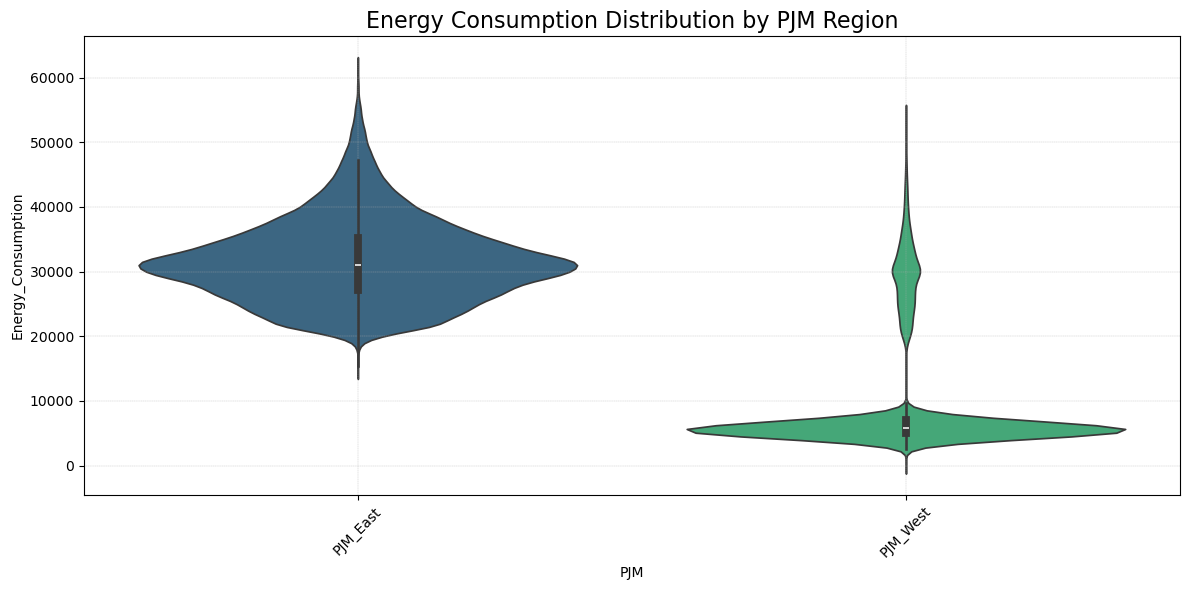

In [33]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(
    data=PJM_Regions,
    x='PJM',
    y='Energy_Consumption',
    palette='viridis'
)
plt.xticks(rotation=45)
plt.title('Energy Consumption Distribution by PJM Region', fontsize=16)
plt.grid(True, which='both', linestyle='--', linewidth=0.25)
plt.tight_layout()
plt.show()

In [34]:
def analyze_outliers(df, column, group_col=None):
    if group_col:
        results = []
        for group in df[group_col].unique():
            group_data = df[df[group_col] == group][column]
            Q1 = group_data.quantile(0.25)
            Q3 = group_data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers = group_data[(group_data < lower_bound) | (group_data > upper_bound)]
            
            results.append({
                'Group': group,
                'Q1': Q1,
                'Median': group_data.median(),
                'Q3': Q3,
                'IQR': IQR,
                'Lower Bound': lower_bound,
                'Upper Bound': upper_bound,
                'Outlier Count': len(outliers),
                'Outlier %': (len(outliers) / len(group_data)) * 100,
                'Min Value': group_data.min(),
                'Max Value': group_data.max()
            })
        
        return pd.DataFrame(results)
    else:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

outlier_stats = analyze_outliers(PJM_Regions, 'Energy_Consumption', 'PJM')
print(outlier_stats)

      Group       Q1   Median       Q3     IQR  Lower Bound  Upper Bound  \
0  PJM_East  27179.0  31062.0  35231.0  8052.0      15101.0      47309.0   
1  PJM_West   5073.0   5823.0   7088.0  2015.0       2050.5      10110.5   

   Outlier Count  Outlier %  Min Value  Max Value  
0           4028   2.287207    14544.0    62009.0  
1          32897  18.679802      487.0    54030.0  


In [35]:
outlier_stats= analyze_outliers(df, 'Energy_Consumption', 'Company')
print(outlier_stats)

                             Group       Q1   Median       Q3     IQR  \
0                            Comed   9856.0  11315.0  12699.0  2843.0   
1             Dayton Power & Light   1749.0   2009.0   2279.0   530.0   
2          Amercian Electric Power  13630.0  15310.0  17200.0  3570.0   
3           Duquesne Light Company   1444.0   1630.0   1819.0   375.0   
4                  Dominion Energy   9322.0  10501.0  12378.0  3056.0   
5                      FirstEnergy   6807.0   7700.0   8556.0  1749.0   
6                 Duke Energy Ohio   2687.0   3013.0   3449.0   762.0   
7  East Kentucky Power Cooperative   1185.0   1386.0   1699.0   514.0   

   Lower Bound  Upper Bound  Outlier Count  Outlier %  Min Value  Max Value  
0       5591.5      16963.5           4182   3.347019     7003.0    23753.0  
1        954.0       3074.0           1535   1.265718      982.0     3746.0  
2       8275.0      22555.0            667   0.549999     9581.0    25695.0  
3        881.5       2381.5   

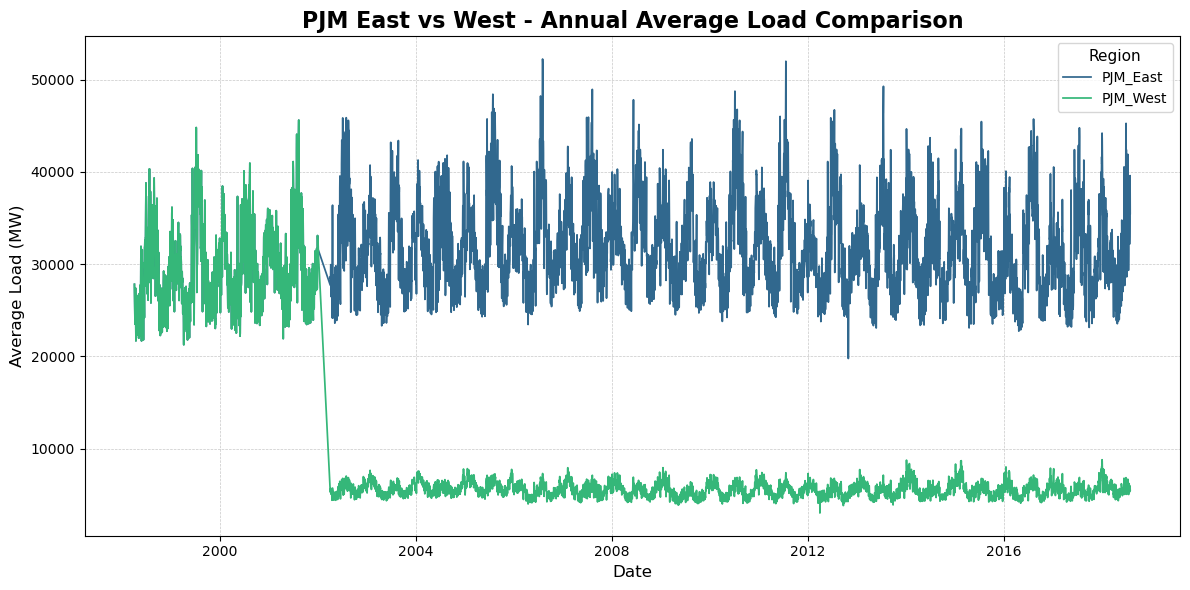

In [36]:
annualy_avg = PJM_Regions.groupby([
    PJM_Regions['Datetime'].dt.date, 
    'PJM'
])['Energy_Consumption'].mean().reset_index()
annualy_avg.columns = ['Date', 'Region', 'Load_MW']

fig, ax = plt.subplots(figsize=(12, 6))
hours = np.arange(24)

sns.lineplot(
    data=annualy_avg, 
    x='Date', 
    y='Load_MW',
    hue='Region', 
    palette='viridis',
    markersize=6,
    linewidth=1.25,
    ax=ax
)

ax.set_title('PJM East vs West - Annual Average Load Comparison', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Average Load (MW)', fontsize=12)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(title='Region', fontsize=10, title_fontsize=11, loc='best')


plt.tight_layout()
plt.show()

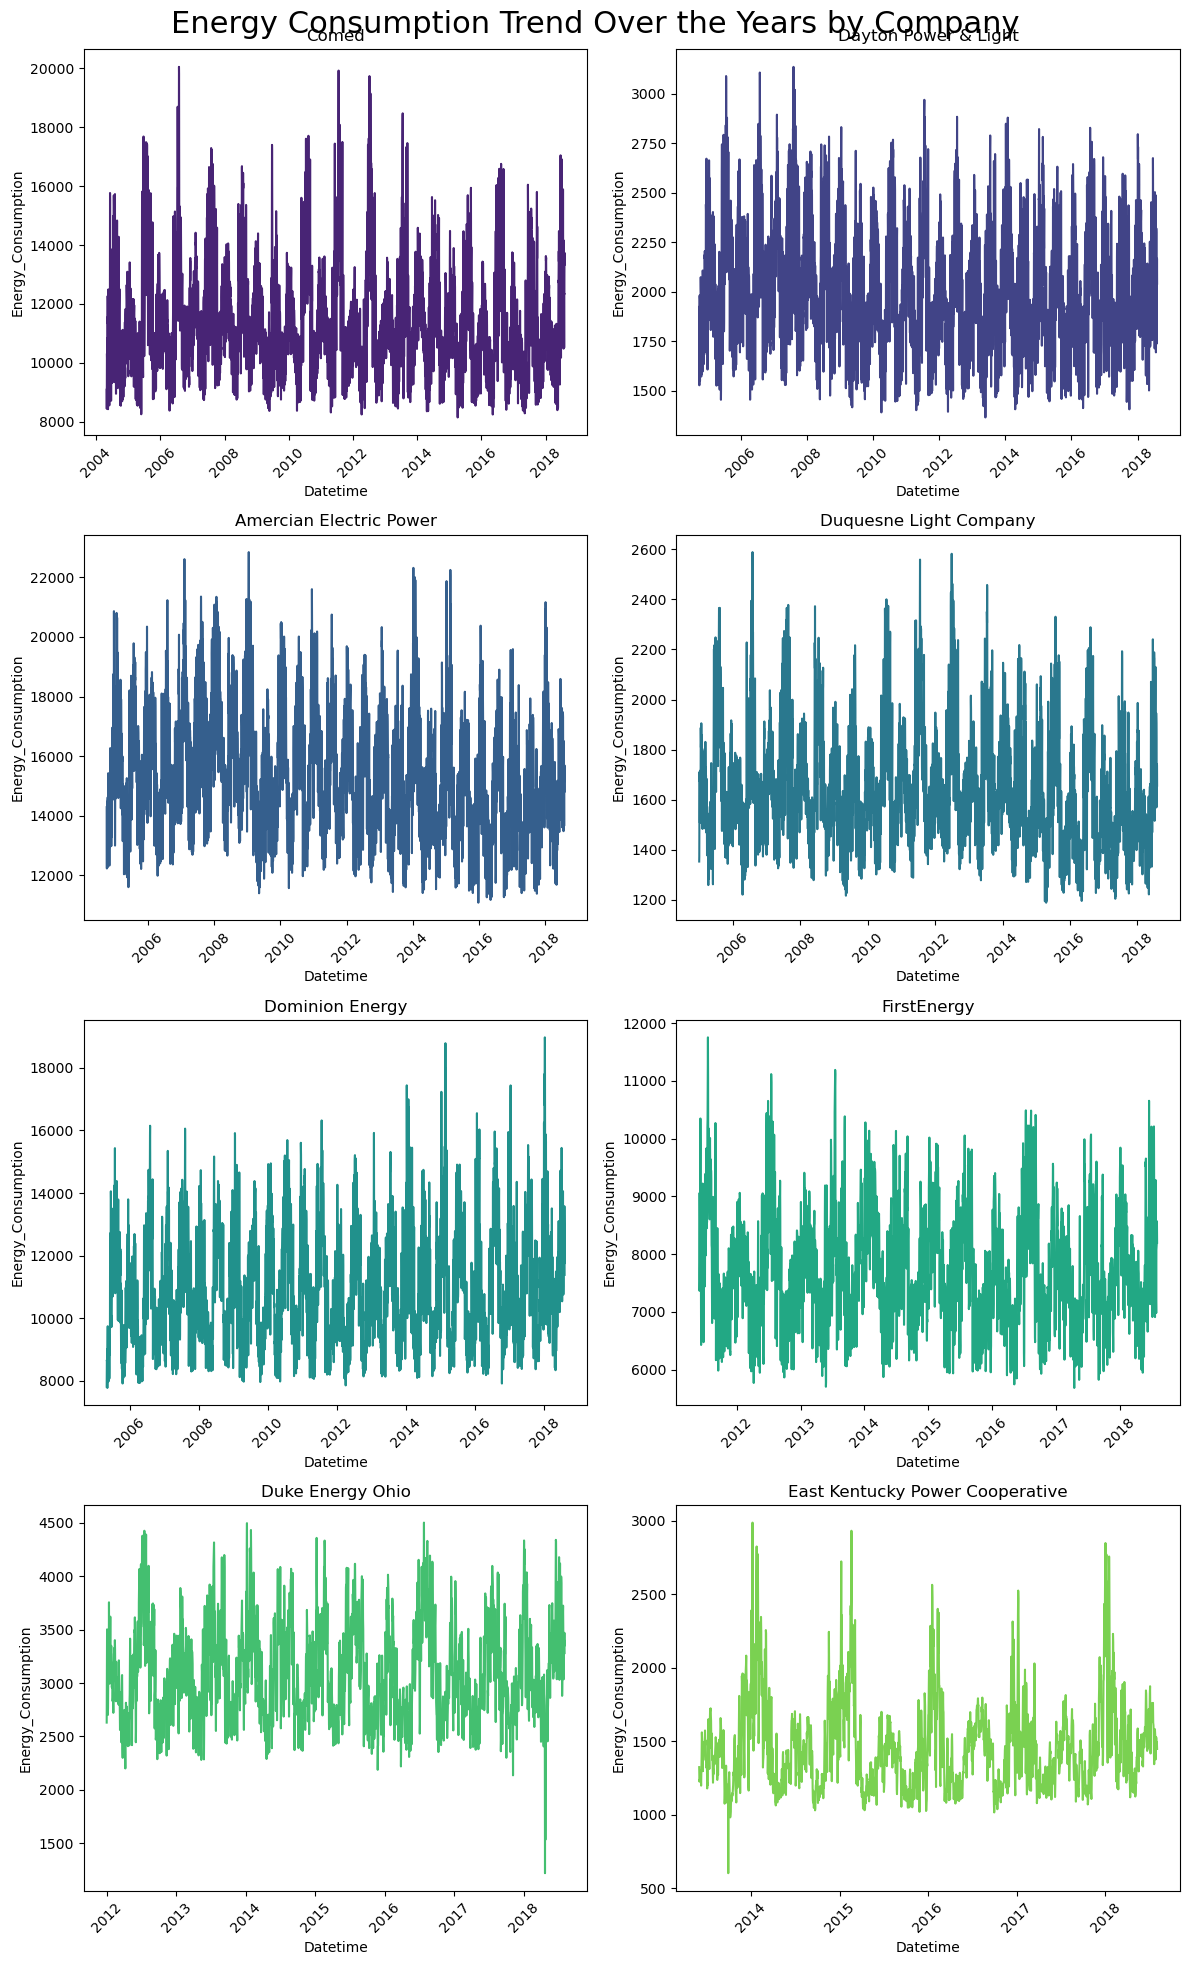

In [37]:
colors = sns.color_palette("viridis", 9) 
fig, ax = plt.subplots(4, 2, figsize=(12, 20), dpi=100)
company_labels = df['Company'].unique()

for i in range(4):
    for j in range(2):
        company = company_labels[i*2 + j]
        company_data = df[df['Company'] == company]
        
        daily_data = company_data.groupby(
            company_data['Datetime'].dt.date
        )['Energy_Consumption'].mean().reset_index()
        
        sns.lineplot(
            data=daily_data, 
            x='Datetime', 
            y='Energy_Consumption', 
            color=colors[i*2 + j],
            ax=ax[i][j]
        )
        ax[i][j].set_title(company)
        ax[i][j].tick_params(axis='x', rotation=45)

plt.suptitle('Energy Consumption Trend Over the Years by Company', fontsize=22)
plt.tight_layout()
plt.show()

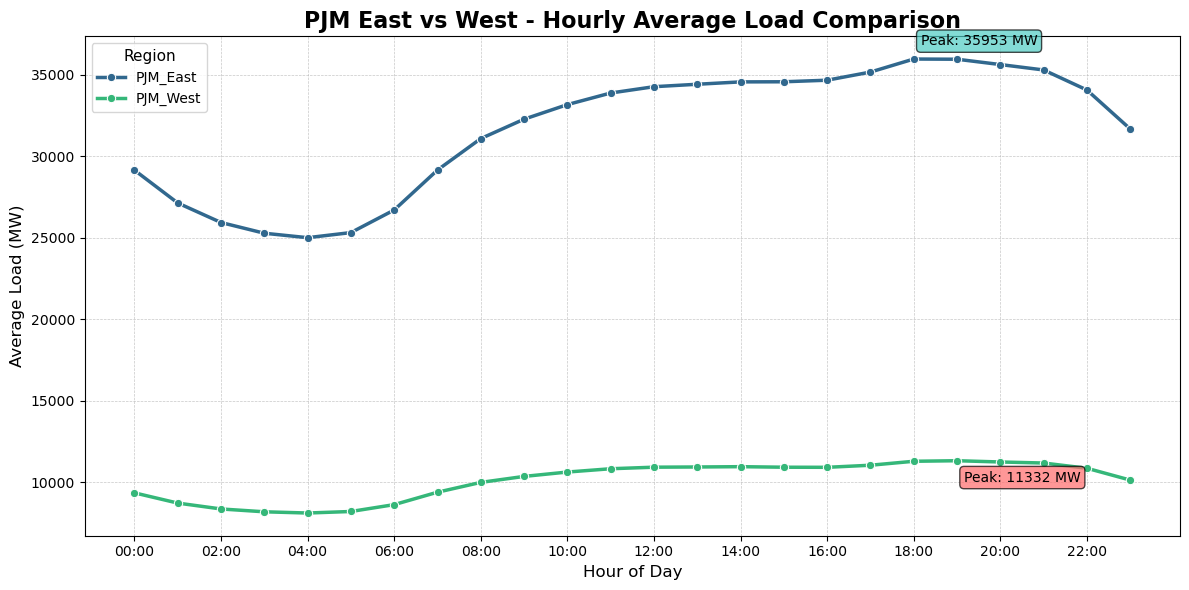

In [38]:
hourly_avg = PJM_Regions.groupby([
    PJM_Regions['Datetime'].dt.hour, 
    'PJM'
])['Energy_Consumption'].mean().reset_index()
hourly_avg.columns = ['Hour', 'Region', 'Load_MW']

fig, ax = plt.subplots(figsize=(12, 6))
hours = np.arange(24)

sns.lineplot(
    data=hourly_avg, 
    x='Hour', 
    y='Load_MW',
    hue='Region', 
    palette='viridis',
    marker='o',
    markersize=6,
    linewidth=2.5,
    ax=ax
)

ax.set_title('PJM East vs West - Hourly Average Load Comparison', fontsize=16, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Average Load (MW)', fontsize=12)
ax.set_xticks(hours[::2])
ax.set_xticklabels([f'{h:02d}:00' for h in hours[::2]])
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(title='Region', fontsize=10, title_fontsize=11, loc='best')

east_data = hourly_avg[hourly_avg['Region'] == 'PJM_East']
west_data = hourly_avg[hourly_avg['Region'] == 'PJM_West']

east_peak_idx = east_data['Load_MW'].idxmax()
west_peak_idx = west_data['Load_MW'].idxmax()

ax.annotate(f"Peak: {east_data.loc[east_peak_idx, 'Load_MW']:.0f} MW", 
            xy=(east_data.loc[east_peak_idx, 'Hour'], east_data.loc[east_peak_idx, 'Load_MW']),
            xytext=(5, 10), textcoords='offset points', 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#4ECDC4', alpha=0.7))

ax.annotate(f"Peak: {west_data.loc[west_peak_idx, 'Load_MW']:.0f} MW", 
            xy=(west_data.loc[west_peak_idx, 'Hour'], west_data.loc[west_peak_idx, 'Load_MW']),
            xytext=(5, -15), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FF6B6B', alpha=0.7))

plt.tight_layout()
plt.show()

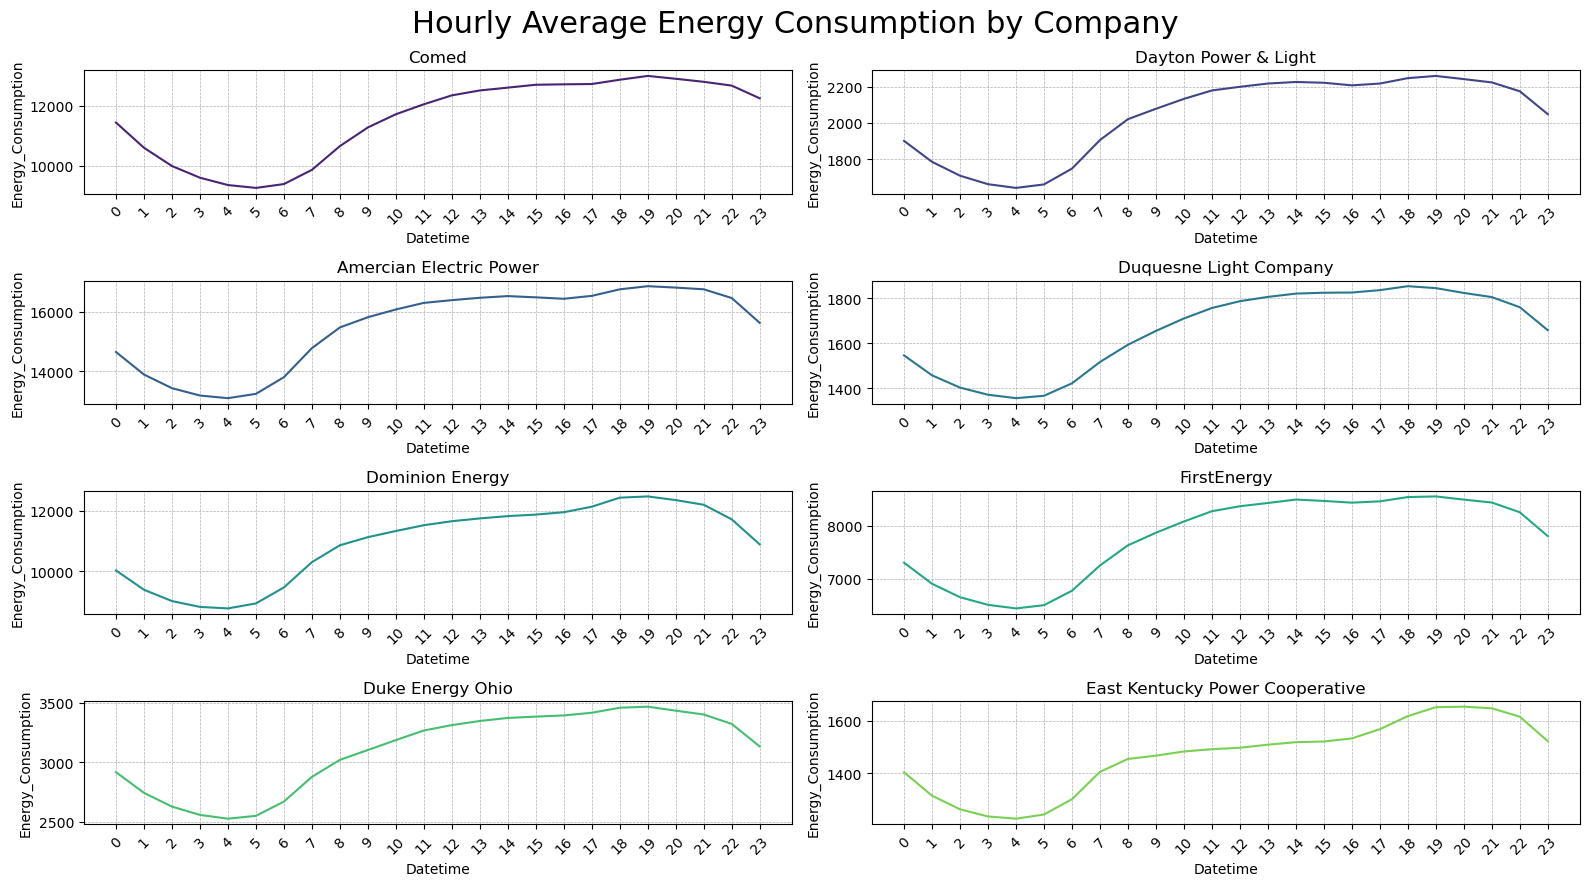

In [39]:
colors = sns.color_palette("viridis", 9) 
fig, ax = plt.subplots(4, 2, figsize=(16, 9), dpi=100)
company_labels = df['Company'].unique()

for i in range(4):
    for j in range(2):
        company = company_labels[i*2 + j]
        company_data = df[df['Company'] == company]
        
        hourly_data = company_data.groupby(
            company_data['Datetime'].dt.hour
        )['Energy_Consumption'].mean().reset_index()
        
        sns.lineplot(
            data=hourly_data, 
            x='Datetime', 
            y='Energy_Consumption', 
            color=colors[i*2 + j],
            ax=ax[i][j]
        )
        ax[i][j].grid(True, which='both', linestyle='--', linewidth=0.5)
        ax[i][j].set_title(company)
        ax[i][j].set_xticks(hours)
        ax[i][j].tick_params(axis='x', rotation=45)

plt.suptitle('Hourly Average Energy Consumption by Company', fontsize=22)
plt.tight_layout()
plt.show()

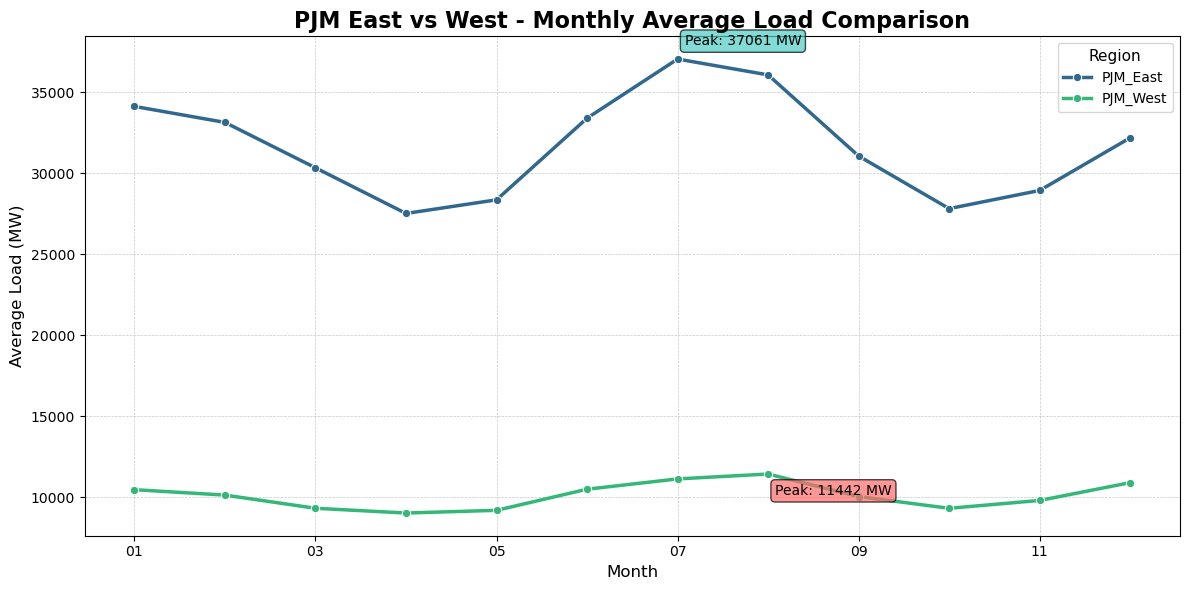

In [40]:
monthly = PJM_Regions.groupby([
    PJM_Regions['Datetime'].dt.month, 
    'PJM'
])['Energy_Consumption'].mean().reset_index()
monthly.columns = ['Month', 'Region', 'Load_MW']

fig, ax = plt.subplots(figsize=(12, 6))
months = np.arange(1, 13)

sns.lineplot(
    data=monthly, 
    x='Month', 
    y='Load_MW',
    hue='Region', 
    palette='viridis',
    marker='o',
    markersize=6,
    linewidth=2.5,
    ax=ax
)

ax.set_title('PJM East vs West - Monthly Average Load Comparison', fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Load (MW)', fontsize=12)
ax.set_xticks(months[::2])
ax.set_xticklabels([f'{m:02d}' for m in months[::2]])
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(title='Region', fontsize=10, title_fontsize=11, loc='best')

east_data = monthly[monthly['Region'] == 'PJM_East']
west_data = monthly[monthly['Region'] == 'PJM_West']

east_peak_idx = east_data['Load_MW'].idxmax()
west_peak_idx = west_data['Load_MW'].idxmax()

ax.annotate(f"Peak: {east_data.loc[east_peak_idx, 'Load_MW']:.0f} MW", 
            xy=(east_data.loc[east_peak_idx, 'Month'], east_data.loc[east_peak_idx, 'Load_MW']),
            xytext=(5, 10), textcoords='offset points', 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#4ECDC4', alpha=0.7))

ax.annotate(f"Peak: {west_data.loc[west_peak_idx, 'Load_MW']:.0f} MW", 
            xy=(west_data.loc[west_peak_idx, 'Month'], west_data.loc[west_peak_idx, 'Load_MW']),
            xytext=(5, -15), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FF6B6B', alpha=0.7))

plt.tight_layout()
plt.show()

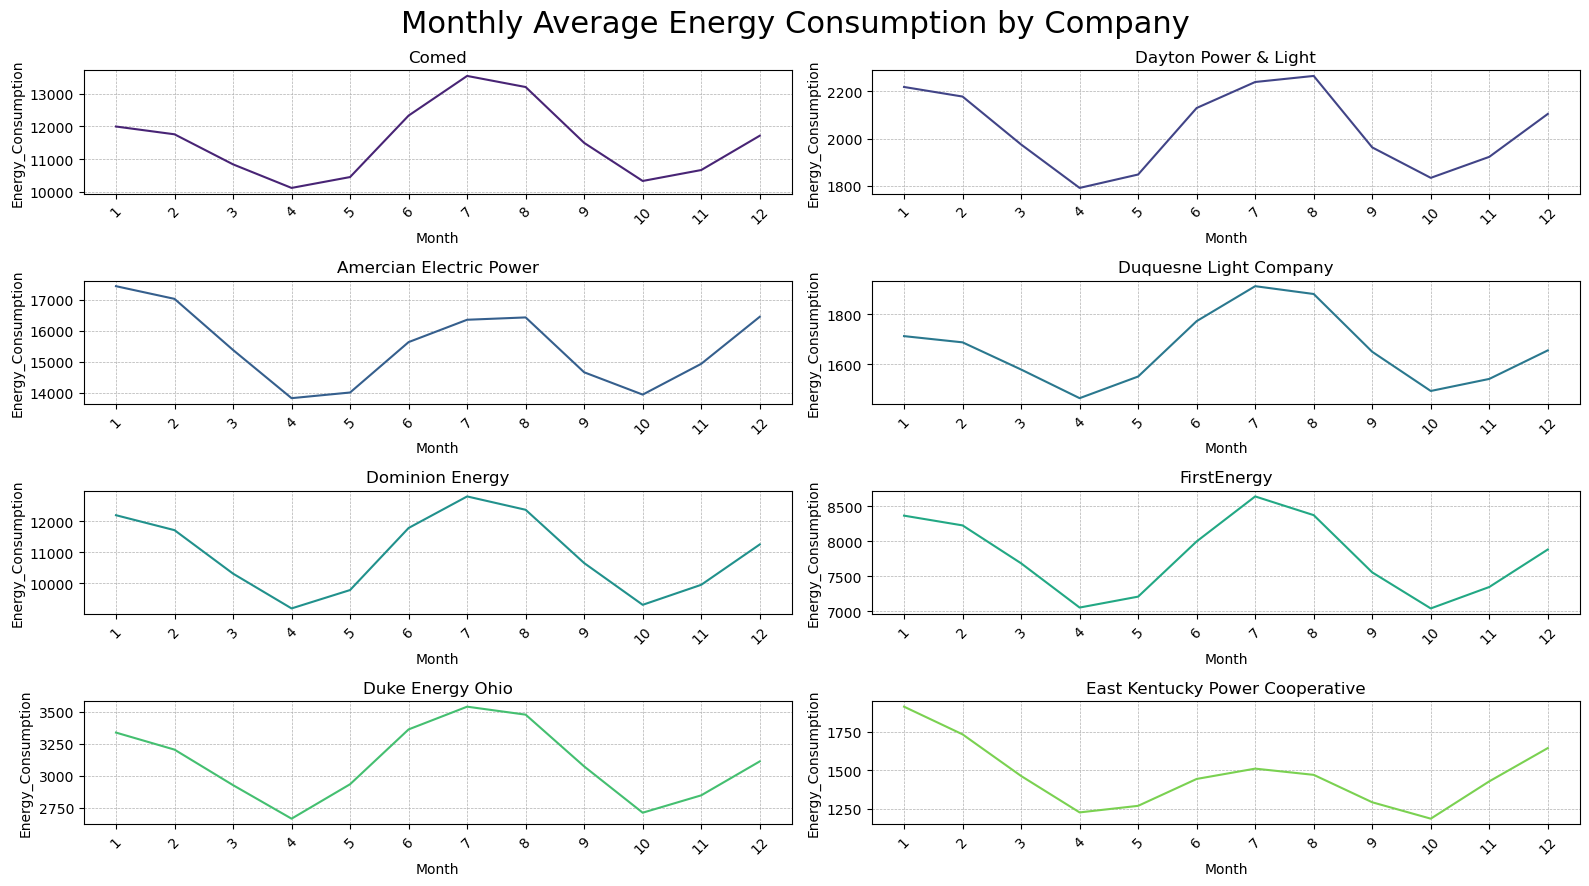

In [41]:
colors = sns.color_palette("viridis", 9) 
fig, ax = plt.subplots(4, 2, figsize=(16, 9), dpi=100)
company_labels = df['Company'].unique()

for i in range(4):
    for j in range(2):
        company = company_labels[i*2 + j]
        company_data = df[df['Company'] == company]
        
        monthly_data = company_data.groupby(
            company_data['Datetime'].dt.month
        )['Energy_Consumption'].mean().reset_index()
        monthly_data.columns = ['Month', 'Energy_Consumption']
        
        sns.lineplot(
            data=monthly_data, 
            x='Month', 
            y='Energy_Consumption', 
            color=colors[i*2 + j],
            ax=ax[i][j]
        )
        ax[i][j].grid(True, which='both', linestyle='--', linewidth=0.5)
        ax[i][j].set_title(company)
        ax[i][j].set_xticks(months)
        ax[i][j].tick_params(axis='x', rotation=45)

plt.suptitle('Monthly Average Energy Consumption by Company', fontsize=22)
plt.tight_layout()
plt.show()

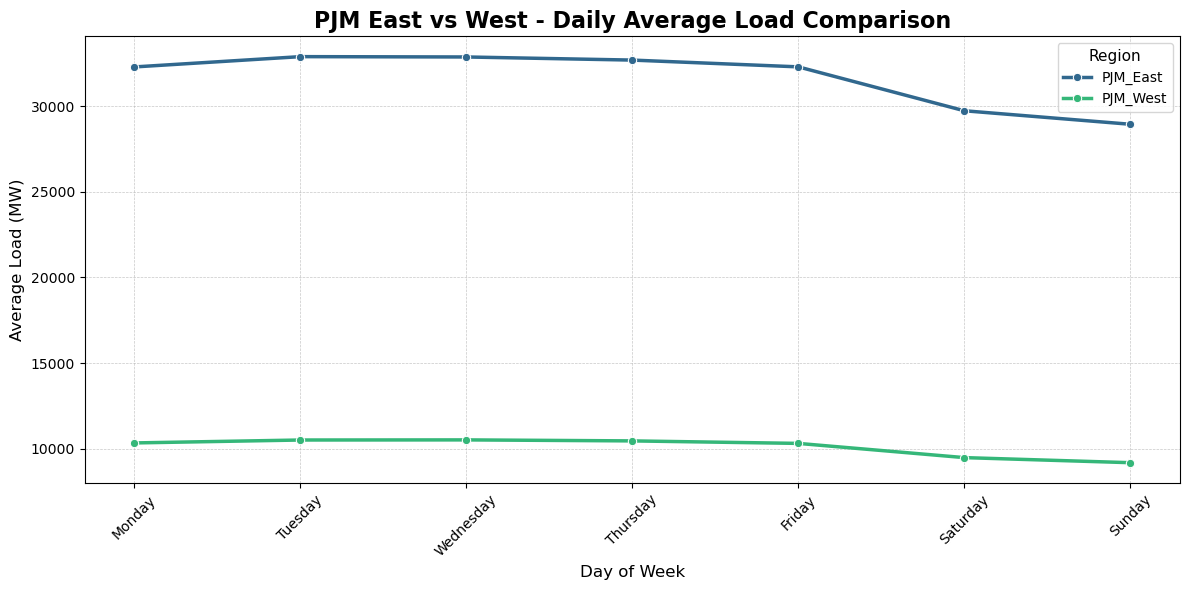

In [42]:
days_of_week = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
DOW_average = PJM_Regions.groupby([
    PJM_Regions['Datetime'].dt.dayofweek, 
    'PJM'
])['Energy_Consumption'].mean().reset_index()
DOW_average.columns = ['Day', 'Region', 'Load_MW']

fig, ax = plt.subplots(figsize=(12, 6))

# Use 0-6 for x-axis, not 1-7
days = np.arange(0, 7)  # Changed from 1-7 to 0-6

sns.lineplot(
    data=DOW_average, 
    x='Day', 
    y='Load_MW',
    hue='Region', 
    palette='viridis',
    marker='o',
    markersize=6,
    linewidth=2.5,
    ax=ax
)

ax.set_title('PJM East vs West - Daily Average Load Comparison', fontsize=16, fontweight='bold')
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Average Load (MW)', fontsize=12)
ax.set_xticks(days) 
ax.set_xticklabels(days_of_week, rotation=45)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(title='Region', fontsize=10, title_fontsize=11, loc='best')

plt.tight_layout()
plt.show()

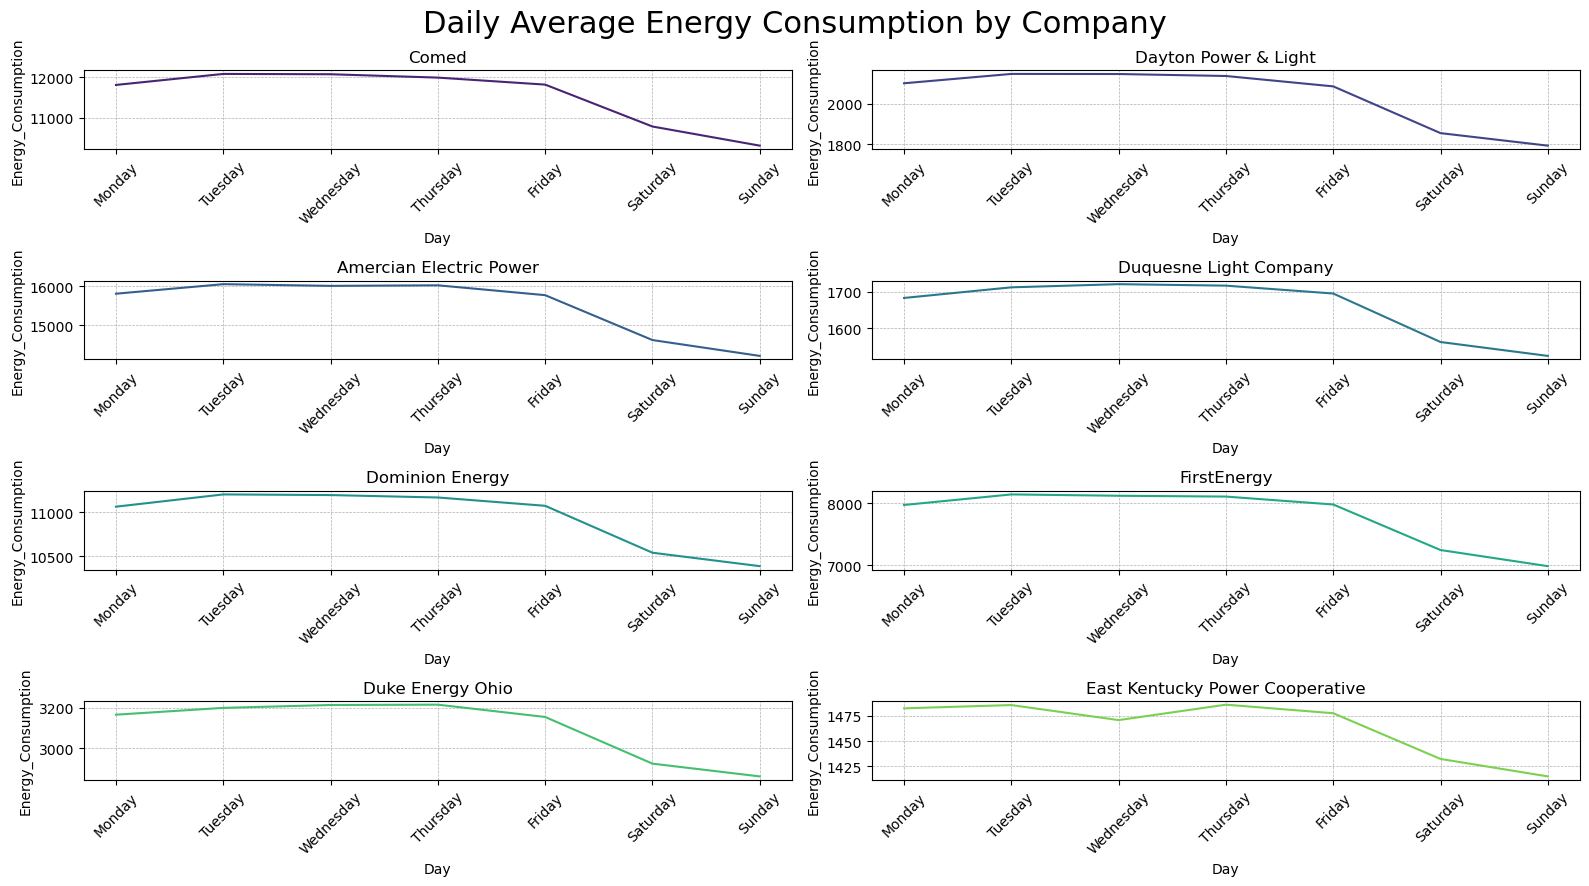

In [43]:
colors = sns.color_palette("viridis", 9) 
fig, ax = plt.subplots(4, 2, figsize=(16, 9), dpi=100)
company_labels = df['Company'].unique()

for i in range(4):
    for j in range(2):
        company = company_labels[i*2 + j]
        company_data = df[df['Company'] == company]
        
        monthly_data = company_data.groupby(
            company_data['Datetime'].dt.dayofweek
        )['Energy_Consumption'].mean().reset_index()
        monthly_data.columns = ['Day', 'Energy_Consumption']
        
        sns.lineplot(
            data=monthly_data, 
            x='Day', 
            y='Energy_Consumption', 
            color=colors[i*2 + j],
            ax=ax[i][j]
        )
        ax[i][j].grid(True, which='both', linestyle='--', linewidth=0.5)
        ax[i][j].set_title(company)
        ax[i][j].set_xticks(range(7))
        ax[i][j].set_xticklabels(days_of_week, rotation=45)

plt.suptitle('Daily Average Energy Consumption by Company', fontsize=22)
plt.tight_layout()
plt.show()

# Feature Engineering

In [44]:
df.reset_index(drop=True, inplace=True)
df.head()

,Datetime,Energy_Consumption,Company
0,2004-05-01 01:00:00,9198.0,Comed
1,2004-05-01 02:00:00,8570.0,Comed
2,2004-05-01 03:00:00,8183.0,Comed
3,2004-05-01 04:00:00,7917.0,Comed
4,2004-05-01 05:00:00,7828.0,Comed


In [45]:
PJM_Regions.head()

,Datetime,PJM,Energy_Consumption
0,1998-04-01 01:00:00,PJM_East,22259.0
1,1998-04-01 02:00:00,PJM_East,21244.0
2,1998-04-01 03:00:00,PJM_East,20651.0
3,1998-04-01 04:00:00,PJM_East,20421.0
4,1998-04-01 05:00:00,PJM_East,20713.0


In [46]:
df["Hour"] = df["Datetime"].dt.hour
df["Year"] = df["Datetime"].dt.year
df["Month"] = df["Datetime"].dt.month
df["WeekDay"] = df["Datetime"].dt.dayofweek
df["Day"] = df["Datetime"].dt.day
df.head()

,Datetime,Energy_Consumption,Company,Hour,Year,Month,WeekDay,Day
0,2004-05-01 01:00:00,9198.0,Comed,1,2004,5,5,1
1,2004-05-01 02:00:00,8570.0,Comed,2,2004,5,5,1
2,2004-05-01 03:00:00,8183.0,Comed,3,2004,5,5,1
3,2004-05-01 04:00:00,7917.0,Comed,4,2004,5,5,1
4,2004-05-01 05:00:00,7828.0,Comed,5,2004,5,5,1


In [47]:
def generate_lag_features(df, group_col, target_col, lags=[1]):
    for lag in lags:
        df[f'Lag_{lag}'] = df.groupby(group_col)[target_col].shift(lag)
    return df

generate_lag_features(df, 'Company', 'Energy_Consumption', lags=[1, 2, 3, 24, 168])
df.head()

,Datetime,Energy_Consumption,Company,Hour,Year,Month,WeekDay,Day,Lag_1,Lag_2,Lag_3,Lag_24,Lag_168
0,2004-05-01 01:00:00,9198.0,Comed,1,2004,5,5,1,NaN,NaN,NaN,NaN,NaN
1,2004-05-01 02:00:00,8570.0,Comed,2,2004,5,5,1,9198.0,NaN,NaN,NaN,NaN
2,2004-05-01 03:00:00,8183.0,Comed,3,2004,5,5,1,8570.0,9198.0,NaN,NaN,NaN
3,2004-05-01 04:00:00,7917.0,Comed,4,2004,5,5,1,8183.0,8570.0,9198.0,NaN,NaN
4,2004-05-01 05:00:00,7828.0,Comed,5,2004,5,5,1,7917.0,8183.0,8570.0,NaN,NaN


In [48]:
df["Rolling_mean_24"] = (
    df.groupby("Company")["Energy_Consumption"]
    .rolling(24)
    .mean()
    .reset_index(level=0, drop=True)
)

df["Rolling_std_24"] = (
    df.groupby("Company")["Energy_Consumption"]
    .rolling(24)
    .std()
    .reset_index(level=0, drop=True)
)
df.head()

,Datetime,Energy_Consumption,Company,Hour,Year,Month,WeekDay,Day,Lag_1,Lag_2,Lag_3,Lag_24,Lag_168,Rolling_mean_24,Rolling_std_24
0,2004-05-01 01:00:00,9198.0,Comed,1,2004,5,5,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2004-05-01 02:00:00,8570.0,Comed,2,2004,5,5,1,9198.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2004-05-01 03:00:00,8183.0,Comed,3,2004,5,5,1,8570.0,9198.0,NaN,NaN,NaN,NaN,NaN
3,2004-05-01 04:00:00,7917.0,Comed,4,2004,5,5,1,8183.0,8570.0,9198.0,NaN,NaN,NaN,NaN
4,2004-05-01 05:00:00,7828.0,Comed,5,2004,5,5,1,7917.0,8183.0,8570.0,NaN,NaN,NaN,NaN


In [49]:
df["Exp_Moving_Avg_24"] = (
    df.groupby("Company")["Energy_Consumption"]
    .apply(lambda x: x.ewm(span=24, adjust=False).mean())
    .reset_index(level=0, drop=True)
)

df["Exp_Moving_Avg_24"] = (
    df.groupby("Company")["Exp_Moving_Avg_24"]
    .shift(1)
)

df.head(10)

,Datetime,Energy_Consumption,Company,Hour,Year,Month,WeekDay,Day,Lag_1,Lag_2,Lag_3,Lag_24,Lag_168,Rolling_mean_24,Rolling_std_24,Exp_Moving_Avg_24
0,2004-05-01 01:00:00,9198.0,Comed,1,2004,5,5,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2004-05-01 02:00:00,8570.0,Comed,2,2004,5,5,1,9198.0,NaN,NaN,NaN,NaN,NaN,NaN,9198.000000
2,2004-05-01 03:00:00,8183.0,Comed,3,2004,5,5,1,8570.0,9198.0,NaN,NaN,NaN,NaN,NaN,9147.760000
3,2004-05-01 04:00:00,7917.0,Comed,4,2004,5,5,1,8183.0,8570.0,9198.0,NaN,NaN,NaN,NaN,9070.579200
4,2004-05-01 05:00:00,7828.0,Comed,5,2004,5,5,1,7917.0,8183.0,8570.0,NaN,NaN,NaN,NaN,8978.292864
5,2004-05-01 06:00:00,7806.0,Comed,6,2004,5,5,1,7828.0,7917.0,8183.0,NaN,NaN,NaN,NaN,8886.269435
6,2004-05-01 07:00:00,8082.0,Comed,7,2004,5,5,1,7806.0,7828.0,7917.0,NaN,NaN,NaN,NaN,8799.847880
7,2004-05-01 08:00:00,8267.0,Comed,8,2004,5,5,1,8082.0,7806.0,7828.0,NaN,NaN,NaN,NaN,8742.420050
8,2004-05-01 09:00:00,8830.0,Comed,9,2004,5,5,1,8267.0,8082.0,7806.0,NaN,NaN,NaN,NaN,8704.386446
9,2004-05-01 10:00:00,9381.0,Comed,10,2004,5,5,1,8830.0,8267.0,8082.0,NaN,NaN,NaN,NaN,8714.435530


In [50]:
(df.isna().sum() / len(df))*100

Datetime              0.000000
Energy_Consumption    0.000000
Company               0.000000
Hour                  0.000000
Year                  0.000000
Month                 0.000000
WeekDay               0.000000
Day                   0.000000
Lag_1                 0.001041
Lag_2                 0.002081
Lag_3                 0.003122
Lag_24                0.024977
Lag_168               0.174841
Rolling_mean_24       0.023937
Rolling_std_24        0.023937
Exp_Moving_Avg_24     0.001041
dtype: float64

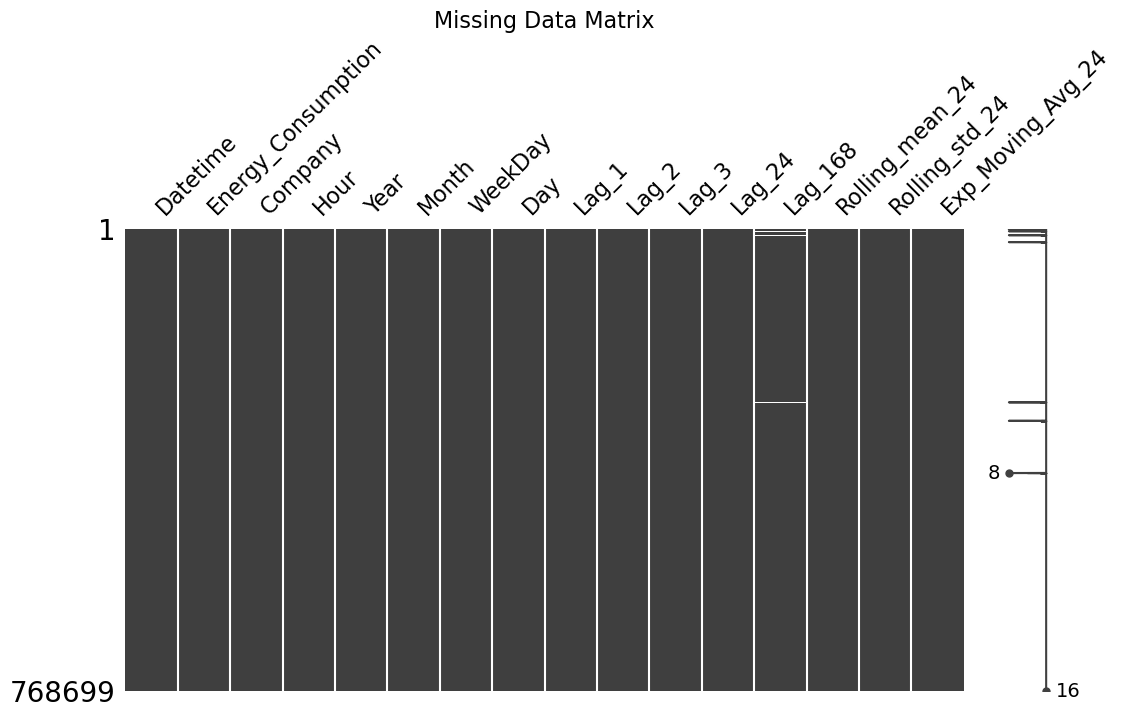

In [51]:
msno.matrix(df, figsize=(12, 6))
plt.title('Missing Data Matrix', fontsize=16)
plt.show()

In [52]:
print(f"Length of DataFrame before dropping NA: {len(df)}")
df.dropna(inplace=True)
print(f"Length of DataFrame after dropping NA: {len(df)}")

Length of DataFrame before dropping NA: 768699
Length of DataFrame after dropping NA: 767355


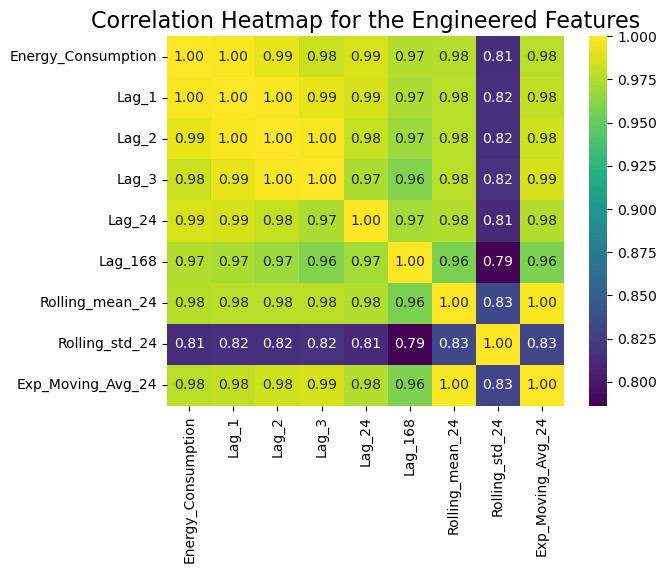

In [53]:
sns.heatmap(df[df.columns[df.dtypes == 'float64']].corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Heatmap for the Engineered Features', fontsize=16)
plt.show()

In [54]:
pd.DataFrame.to_csv(df, 'PJM_Energy_Consumption_Preprocessed.csv', index=False)